`Taller-Semana Tres `
## Dataset:

Es un conjunto de datos de Diabetes corresponde a un estudio clínico con 442 pacientes con el objetivo de analizar los factores de la diabetes.

Docente:` JULIAN HOYOS.`

### Objetivo: Aplicar el proceso de Estadística Inferencial
Objetivo aplicar librerías específicas de Python para realizar análisis de estadística descriptiva e inferencial. Se utilizará el dataset de "Diabetes", analizando la relación entre variables biométricas y la progresión de la enfermedad. Se aplicarán pruebas de hipótesis (T-Test) y Análisis de Varianza (ANOVA). inicio con el archivo que relaciona información de 442 pacientes diabéticos y se tomaron 10 medidas como lo son: Edad, Sexo, peso, presion arterial presion arterial y 6 variables de analisis de sangre, es decir se dividen en:
Demográficas: Edad y Sexo
Físicas: * BMI (IMC): El peso respecto a la estatura.
BP: La presión arterial.
Análisis de Laboratorio (S1 a S6): Son indicadores.

Se anexa una descripcion y tipo de variable del data, con el objetivo de analizar de manera visual, los factores de la diabetes. Las variables y la descripción, se anexan a continuación:


| **Variable** | **Descripción**                                | **¿Para qué sirve?**                                             | **Tipo de variable**                              |
| ------------ | ---------------------------------------------- | ---------------------------------------------------------------- | ------------------------------------------------- |
| **AGE**      | Edad del paciente (estandarizada)              | Analizar el efecto de la edad sobre la progresión de la diabetes | Cuantitativa continua                             |
| **SEX**      | Sexo del paciente (codificado y estandarizado) | Evaluar diferencias en la progresión según sexo                  | Cualitativa dicotómica (codificada numéricamente) |
| **BMI**      | Índice de masa corporal                        | Estudiar la relación entre obesidad y progresión de la diabetes  | Cuantitativa continua                             |
| **BP**       | Presión arterial media                         | Evaluar impacto cardiovascular en la progresión de la enfermedad | Cuantitativa continua                             |
| **S1**       | Colesterol total sérico                        | Predictor del metabolismo lipídico                               | Cuantitativa continua                             |
| **S2**       | Colesterol LDL sérico                          | Evaluar dislipidemia asociada a diabetes                         | Cuantitativa continua                             |
| **S3**       | Colesterol HDL sérico                          | Analizar efecto protector cardiovascular                         | Cuantitativa continua                             |
| **S4**       | Relación colesterol total / HDL                | Indicador de riesgo cardiovascular global                        | Cuantitativa continua                             |
| **S5**       | Logaritmo del triglicérido sérico              | Medir alteraciones metabólicas lipídicas                         | Cuantitativa continua                             |
| **S6**       | Glucosa sérica                                 | Evaluar control metabólico                                       | Cuantitativa continua                             |
| **Y**        | Progresión de la diabetes al año               | **Variable respuesta** del modelo                                | Cuantitativa continua (dependiente)               |


In [ ]:
#Cargar las librerías necesarias
import numpy as np # Manejo de Calculos Matemáticos.
import pandas as pd #  Pandas: librería para la manipulación y análisis de datos.
import seaborn as sns # Creación gráficos estadísticos.
import matplotlib.pyplot as plt # Creación de gráficos en dos dimensiones
from sklearn.preprocessing import StandardScaler # Normalizar los datos, comparación de variables con distintas Unidades (Z-score).
#SciPy: Librería clave para Estadística Inferencial (T-Test, ANOVA, Curtosis)
from scipy import stats

In [ ]:
url = "https://www4.stat.ncsu.edu/~boos/var.select/diabetes.tab.txt" # Carga la url

In [ ]:
df = pd.read_csv(url, sep="\t") # Carga el dataset
df

,AGE,SEX,BMI,BP,S1,S2,S3,S4,S5,S6,Y
0,59,2,32.1,101.00,157,93.2,38.0,4.00,4.8598,87,151
1,48,1,21.6,87.00,183,103.2,70.0,3.00,3.8918,69,75
2,72,2,30.5,93.00,156,93.6,41.0,4.00,4.6728,85,141
3,24,1,25.3,84.00,198,131.4,40.0,5.00,4.8903,89,206
4,50,1,23.0,101.00,192,125.4,52.0,4.00,4.2905,80,135
...,...,...,...,...,...,...,...,...,...,...,...
437,60,2,28.2,112.00,185,113.8,42.0,4.00,4.9836,93,178
438,47,2,24.9,75.00,225,166.0,42.0,5.00,4.4427,102,104
439,60,2,24.9,99.67,162,106.6,43.0,3.77,4.1271,95,132
440,36,1,30.0,95.00,201,125.2,42.0,4.79,5.1299,85,220


In [ ]:
df.shape # filas y columnas.

(442, 11)

In [ ]:
df.head(15)          # primeras 10 filas.



,AGE,SEX,BMI,BP,S1,S2,S3,S4,S5,S6,Y
0,59,2,32.1,101.0,157,93.2,38.0,4.00,4.8598,87,151
1,48,1,21.6,87.0,183,103.2,70.0,3.00,3.8918,69,75
2,72,2,30.5,93.0,156,93.6,41.0,4.00,4.6728,85,141
3,24,1,25.3,84.0,198,131.4,40.0,5.00,4.8903,89,206
4,50,1,23.0,101.0,192,125.4,52.0,4.00,4.2905,80,135
5,23,1,22.6,89.0,139,64.8,61.0,2.00,4.1897,68,97
6,36,2,22.0,90.0,160,99.6,50.0,3.00,3.9512,82,138
7,66,2,26.2,114.0,255,185.0,56.0,4.55,4.2485,92,63
8,60,2,32.1,83.0,179,119.4,42.0,4.00,4.4773,94,110
9,29,1,30.0,85.0,180,93.4,43.0,4.00,5.3845,88,310


Estadística Descriptiva:
se determinaran  las medidas de posición central, dispersión, asimetría y curtosis para la variable objetivo `Y` y la variable `BMI`.

--- ESTADÍSTICAS PARA LA VARIABLE: Y ---
Media (Promedio): 152.13
Mediana:          140.50
Moda:             72
Varianza:             5943.33
Desviación Estándar:  77.09
Asimetría (Skewness): 0.44
Curtosis:             -0.89


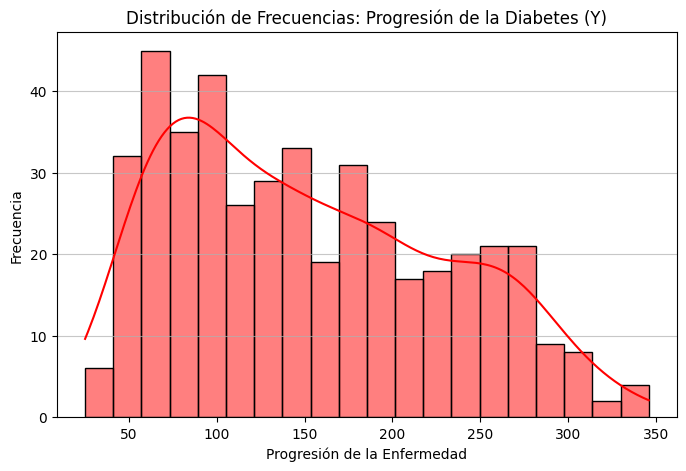

In [ ]:

variable = 'Y' # (Variable dependiente)

print(f"--- ESTADÍSTICAS PARA LA VARIABLE: {variable} ---")
# Medidas de Posición Central
print(f"Media (Promedio): {df[variable].mean():.2f}")
print(f"Mediana:          {df[variable].median():.2f}")
print(f"Moda:             {df[variable].mode()[0]}")

# Medidas de Dispersión
print(f"Varianza:             {df[variable].var():.2f}")
print(f"Desviación Estándar:  {df[variable].std():.2f}")

# Medidas de Forma
print(f"Asimetría (Skewness): {df[variable].skew():.2f}")
print(f"Curtosis:             {stats.kurtosis(df[variable]):.2f}")

# Visualización: Histograma con curva de densidad
plt.figure(figsize=(8, 5))
sns.histplot(df[variable], kde=True, color='red', bins=20)
plt.title('Distribución de Frecuencias: Progresión de la Diabetes (Y)')
plt.xlabel('Progresión de la Enfermedad')
plt.ylabel('Frecuencia')
plt.grid(axis='y', alpha=0.7)
plt.show()

Se desarrolla un Mapa de Calor con las correlaciones, para Intensidad: Entre más fuerte es el color, más "conectadas" están las variables y Tono: si la relación es directa (positiva) o inversa (negativa).

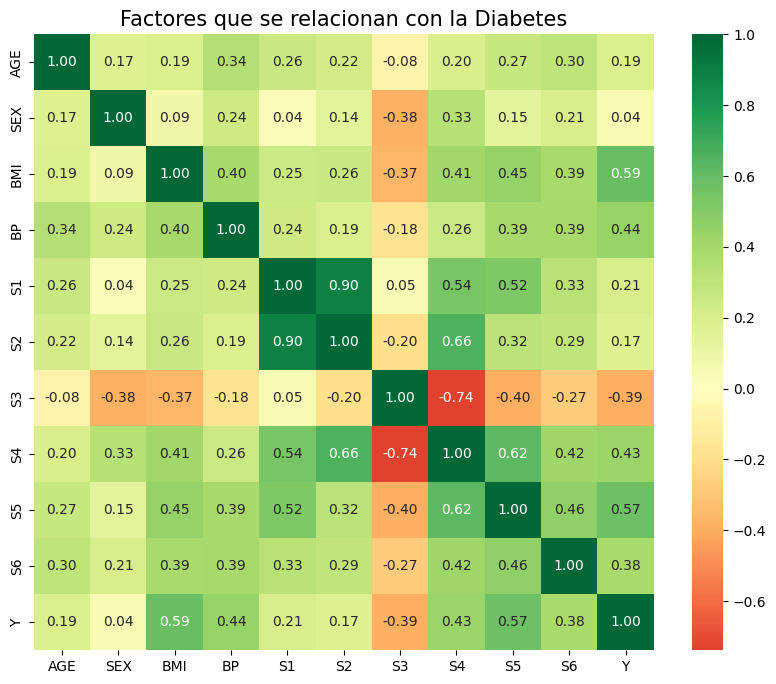

In [ ]:
correlaciones = df.corr()

# Creamos el gráfico de calor
plt.figure(figsize=(10, 8))
sns.heatmap(correlaciones, annot=True, cmap='RdYlGn', fmt=".2f", center=0)

plt.title('Factores que se relacionan con la Diabetes', fontsize=15)
plt.show()

El anterior mapa de calor muestra que que la relacion entre BMI y Y, es fuerte
de 0,59, lo cual implica que si el peso es el factor que más influye en que la enfermedad avance rápido. El valor de -0.39, relaciona a S3 y Y, es decir que mientras más alto sea el colesterol menor es la progresión de la diabetes.

Ademas si en la Edad es de 0,19 en esta matriz, implica que la diabetes no progresa más rápido solo por ser adulto, puede ser que exista un joven con un IMC alto está en más riesgo que un anciano con un IMC controlado. Si las relaciones son de grupos S1 y S2 de 0,89 implica que LDL y el colesterol estan relacionados , es decir se puede usar solo uno de ellos y se tendria el mismo resultado.

##  Estadística Inferencial: Prueba T de Student
Se determinara si existe una diferencia estadísticamente significativa en la progresión de la diabetes (Variable `Y`) entre hombres y mujeres (Variable `SEX`)

`Hipótesis Nula (H0)`: No hay diferencia en la media de progresión entre los sexos.
`Hipótesis Alternativa (H1)`: Sí existe una diferencia en las medias.

 RESULTADOS DEL T-TEST 
Estadístico T: -0.9041
Valor P (p-value): 0.3664
Conclusión: No podemos rechazar H0. No hay evidencia de diferencia significativa en la progresión.


/tmp/ipykernel_5335/201282747.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='SEX', y='Y', data=df, palette='Set2')


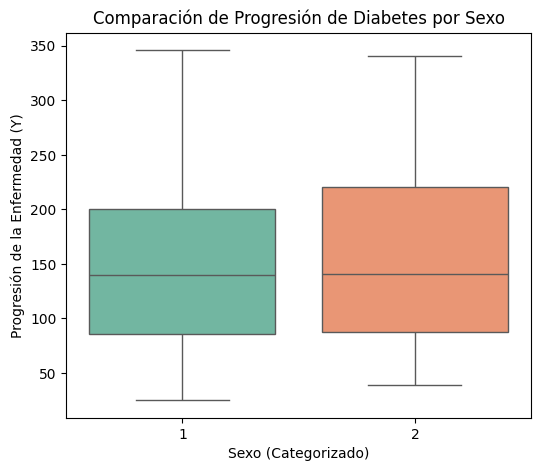

In [ ]:

# En este dataset, el SEXO está codificado generalmente como 1 y 2
sexo_1 = df[df['SEX'] == 1]['Y']
sexo_2 = df[df['SEX'] == 2]['Y']

# Realizamos el T-Test usando la librería SciPy
t_stat, p_valor_t = stats.ttest_ind(sexo_1, sexo_2)

print(" RESULTADOS DEL T-TEST ")
print(f"Estadístico T: {t_stat:.4f}")
print(f"Valor P (p-value): {p_valor_t:.4f}")

if p_valor_t < 0.05:
    print("Conclusión: Rechazamos H0. Existe una diferencia significativa en la progresión de la diabetes.")
else:
    print("Conclusión: No podemos rechazar H0. No hay evidencia de diferencia significativa en la progresión.")

# Visualización comparativa (Boxplot)
plt.figure(figsize=(6, 5))
sns.boxplot(x='SEX', y='Y', data=df, palette='Set2')
plt.title('Comparación de Progresión de Diabetes por Sexo')
plt.xlabel('Sexo (Categorizado)')
plt.ylabel('Progresión de la Enfermedad (Y)')
plt.show()

In [ ]:
df_t = len(sexo_1) + len(sexo_2) - 2
alfa = 0.05

# Valor t crítico (frontera de la región de rechazo para dos colas)
t_critico = stats.t.ppf(1 - alfa/2, df_t)

# 4. Lógica de decisión
if p_valor_t < alfa:
    conclusion = "SE RECHAZA H0\nExiste diferencia significativa"
    color_texto = "darkred"
else:
    conclusion = "NO SE RECHAZA H0\nNo hay diferencia significativa"
    color_texto = "darkgreen"

# Imprimir resultados en texto
print("--- RESULTADOS DEL T-TEST ---")
print(f"Estadístico T obtenido: {t_stat:.4f}")
print(f"Valor T Crítico (Frontera): ±{t_critico:.4f}")
print(f"Valor P (p-value): {p_valor_t:.4f}")
print(f"Conclusión: {conclusion.replace(chr(10), ' - ')}")

--- RESULTADOS DEL T-TEST ---
Estadístico T obtenido: -0.9041
Valor T Crítico (Frontera): ±1.9654
Valor P (p-value): 0.3664
Conclusión: NO SE RECHAZA H0 - No hay diferencia significativa


/tmp/ipykernel_5335/4075820121.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='SEX', y='Y', data=df, palette='Set2', ax=ax2)


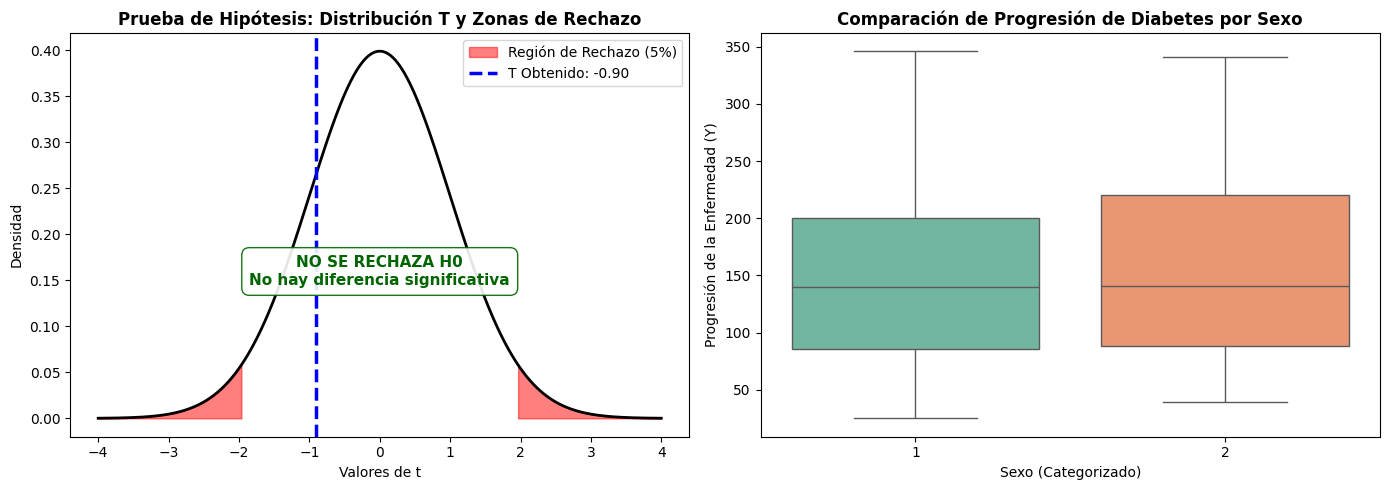

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
# Crear el eje X (Rango de valores posibles para t)
x = np.linspace(-4, 4, 1000)
# Calcular la altura de la campana (Densidad de Probabilidad)
y = stats.t.pdf(x, df_t)

# Dibujar la Distribución Gauss
ax1.plot(x, y, color='black', linewidth=2)

# Sombrear la región de rechazo izquierda (Rojo)
x_izq = x[x <= -t_critico]
ax1.fill_between(x_izq, stats.t.pdf(x_izq, df_t), color='red', alpha=0.5, label='Región de Rechazo (5%)')

# Sombrear la región de rechazo derecha (Rojo)
x_der = x[x >= t_critico]
ax1.fill_between(x_der, stats.t.pdf(x_der, df_t), color='red', alpha=0.5)

# Dibujar una línea azul donde cayó exactamente nuestro estadístico T
ax1.axvline(t_stat, color='blue', linestyle='--', linewidth=2.5, label=f'T Obtenido: {t_stat:.2f}')

# Títulos y configuraciones de la Campana
ax1.set_title('Prueba de Hipótesis: Distribución T y Zonas de Rechazo', fontsize=12, fontweight='bold')
ax1.set_xlabel('Valores de t', fontsize=10)
ax1.set_ylabel('Densidad', fontsize=10)
ax1.legend(loc='upper right')

# Añadir el texto con la conclusión en el centro de la gráfica
ax1.text(x=0, y=max(y)*0.4, s=conclusion, ha='center', va='center', fontsize=11, fontweight='bold',
         color=color_texto, bbox=dict(facecolor='white', edgecolor=color_texto, boxstyle='round,pad=0.5', alpha=0.9))

#  BOXPLOT (Datos reales)
sns.boxplot(x='SEX', y='Y', data=df, palette='Set2', ax=ax2)
ax2.set_title('Comparación de Progresión de Diabetes por Sexo', fontsize=12, fontweight='bold')
ax2.set_xlabel('Sexo (Categorizado)', fontsize=10)
ax2.set_ylabel('Progresión de la Enfermedad (Y)', fontsize=10)

# Ajustar y mostrar todo el tablero
plt.tight_layout()
plt.show()

##  `Análisis de Varianza ANOVA`
Podemos afrimar que la Presión Arterial Media (`BP`) tiene un efecto significativo sobre la progresión de la diabetes
Para aplicar ANOVA, categorizaremos la presión arterial en tres grupos (Baja, Media, Alta) y luego verificaremos si las medias de progresión (`Y`) varían entre estos tres grupos.

RESULTADOS-ANOVA 
Estadístico F: 50.0139
Valor P (p-value): 0.0000000000
Conclusión: Rechazamos H0. La presión arterial (Alta/Media/Baja) tiene un efecto significativo en la progresión de la diabetes.


/tmp/ipykernel_5335/619348814.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='BP_Categoria', y='Y', data=df, palette='muted')


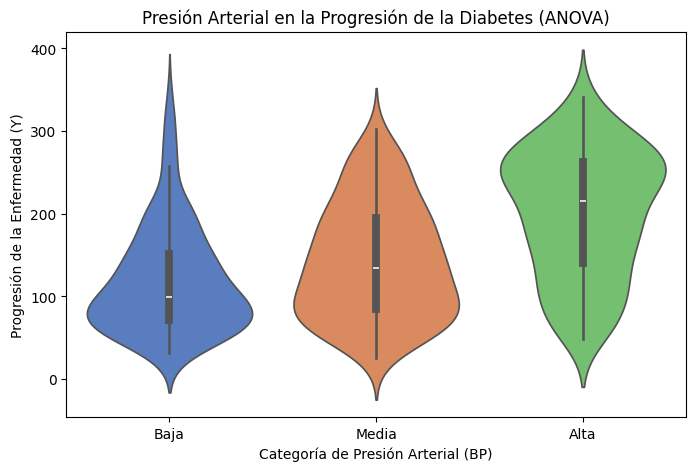

In [ ]:

# Primero, creamos una nueva columna categórica para la Presión Arterial (BP)
# Dividiremos la BP en 3 grupos: Baja, Media, Alta basándonos en cuantiles
df['BP_Categoria'] = pd.qcut(df['BP'], q=3, labels=['Baja', 'Media', 'Alta'])

# Separamos los datos de progresión 'Y' para cada grupo de presión arterial
bp_baja = df[df['BP_Categoria'] == 'Baja']['Y']
bp_media = df[df['BP_Categoria'] == 'Media']['Y']
bp_alta = df[df['BP_Categoria'] == 'Alta']['Y']

# Ejecutamos el ANOVA de una vía (One-way ANOVA) con SciPy
f_stat, p_valor_anova = stats.f_oneway(bp_baja, bp_media, bp_alta)

print("RESULTADOS-ANOVA ")
print(f"Estadístico F: {f_stat:.4f}")
print(f"Valor P (p-value): {p_valor_anova:.10f}")

if p_valor_anova < 0.05:
    print("Conclusión: Rechazamos H0. La presión arterial (Alta/Media/Baja) tiene un efecto significativo en la progresión de la diabetes.")
else:
    print("Conclusión: No podemos rechazar H0. No hay diferencias significativas.")

# Visualización del ANOVA (Violin Plot para ver la distribución completa)
plt.figure(figsize=(8, 5))
sns.violinplot(x='BP_Categoria', y='Y', data=df, palette='muted')
plt.title('Presión Arterial en la Progresión de la Diabetes (ANOVA)')
plt.xlabel('Categoría de Presión Arterial (BP)')
plt.ylabel('Progresión de la Enfermedad (Y)')
plt.show()

En este bloque se desarrollara Anova en el indice de masa corporal.

/tmp/ipykernel_5335/2664508186.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='BMI_Categoria', y='Y', data=df, palette='Set3', inner=None)
/tmp/ipykernel_5335/2664508186.py:42: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  medias_bmi = df.groupby('BMI_Categoria')['Y'].mean()


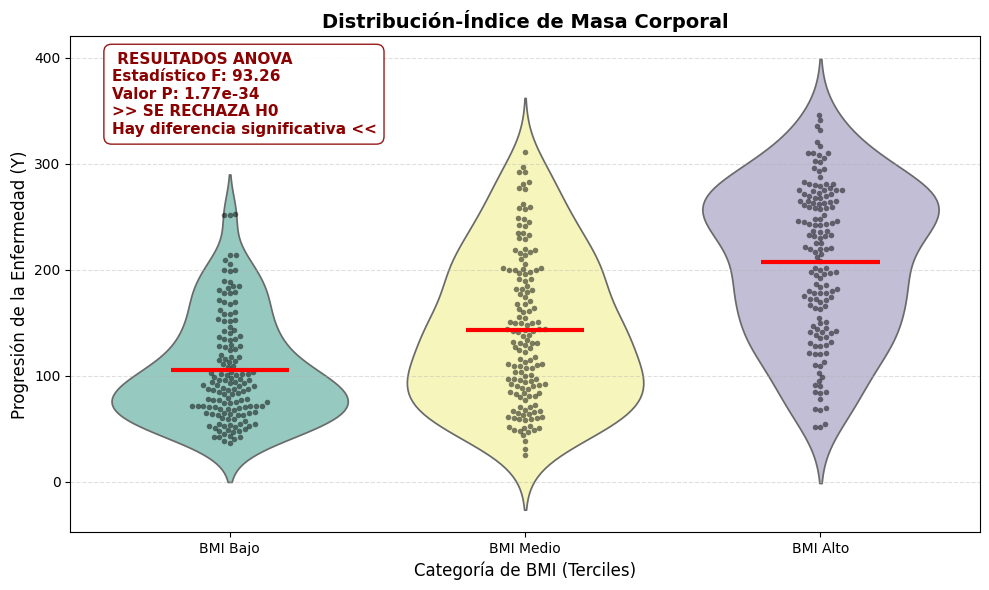

In [ ]:


df['BMI_Categoria'] = pd.qcut(df['BMI'], q=3, labels=['BMI Bajo', 'BMI Medio', 'BMI Alto'])

bmi_bajo = df[df['BMI_Categoria'] == 'BMI Bajo']['Y']
bmi_medio = df[df['BMI_Categoria'] == 'BMI Medio']['Y']
bmi_alto = df[df['BMI_Categoria'] == 'BMI Alto']['Y']

f_stat_bmi, p_valor_bmi = stats.f_oneway(bmi_bajo, bmi_medio, bmi_alto)

if p_valor_bmi < 0.05:
    decision_bmi = "SE RECHAZA H0\nHay diferencia significativa"
    color_texto = "darkred"
else:
    decision_bmi = "NO SE RECHAZA H0\nNo hay diferencia"
    color_texto = "darkgreen"
plt.figure(figsize=(10, 6))
# Creamos el Violinplot y el Swarmplot
sns.violinplot(x='BMI_Categoria', y='Y', data=df, palette='Set3', inner=None)
sns.swarmplot(x='BMI_Categoria', y='Y', data=df, color='black', alpha=0.5, size=4)

plt.title('Distribución-Índice de Masa Corporal', fontsize=14, fontweight='bold')
plt.xlabel('Categoría de BMI (Terciles)', fontsize=12)
plt.ylabel('Progresión de la Enfermedad (Y)', fontsize=12)

if p_valor_bmi < 0.0001:
    p_str = f"{p_valor_bmi:.2e}"
else:
    p_str = f"{p_valor_bmi:.6f}"

# Añadimos el cuadro de resultados
texto_resultados_bmi = (
    f" RESULTADOS ANOVA \n"
    f"Estadístico F: {f_stat_bmi:.2f}\n"
    f"Valor P: {p_str}\n"
    f">> {decision_bmi} <<"
)

plt.text(x=-0.4, y=df['Y'].max() * 0.95, s=texto_resultados_bmi,
         fontsize=11, fontweight='bold', color=color_texto,
         bbox=dict(facecolor='white', edgecolor=color_texto, boxstyle='round,pad=0.5', alpha=0.9))

# Trazamos las líneas rojas de las medias de cada grupo
medias_bmi = df.groupby('BMI_Categoria')['Y'].mean()
for i, media in enumerate(medias_bmi):
    plt.hlines(y=media, xmin=i-0.2, xmax=i+0.2, color='red', linewidth=3, zorder=5)

plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

Esto comprueba, con un altísimo nivel de confianza estadística, que el sobrepeso y la obesidad son aceleradores determinantes en la severidad y avance de la diabetes.

Los indice de Masa Corporal (BMI) revela correlación positiva con el deterioro de la salud del paciente. Tanto en la gráfica de progresión de la enfermedad (Y) como en la de niveles de azúcar (S6), a medida que el paciente esta en lq categoría de "BMI bajo" a "BMI alto", los promedios de ambas variables aumentan, es decir el peso corporal es un factor determinante en la diabetes.

Ademas en la variable Sexo muestra una distribución homogénea y menos discriminante. el diagrama de barras que comparan hombres y mujeres presentan alturas similares tanto para la variable (Y) como la glucosa (S6), por lo tanto el impacto metabólico del BMI domina sobre las diferencias biológicas basales.


Bibliografía
Boschetti, A., & Massaron, L. (2018). Python Data Science Essentials: A practitioner's guide covering essential data science principles, tools, and techniques (pp. 281-331). Packt Publishing Ltd.

Fuentes, A. (2018). Become a Python data analyst: Perform exploratory data analysis and gain insight into scientific computing using Python (pp. 69-118). Packt Publishing, Limited.

Mehta, H. (2015). Mastering Python Scientific Computing (pp. 163-198). Packt Publishing, Limited.

Yim, A., Chung, C., & Yu, A. (2018). Matplotlib for Python developers: Effective techniques for data visualization with Python (2.ª ed., pp. 21-54). Packt Publishing, Limited.